## Objetivo

### Evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas en el 2024. 
- Para ello se trabajará con datos reales de TomTom Traffic Index y OECD Cities.
- Los datos se limpiarán, combinarán y analizarán para identificar en qué ciudades conviene invertir en infraestructura de transporte.

---
### 1. Se guardan los DataFrames `tomtom_traffic` y `oecd_city_economy` en las variables `traffic` y `eco` respectivamente.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [3]:
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [4]:
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


---
### 2. Antes de combinar los datasets, se inspecciona su estructura, tipos de datos, columnas y valores faltantes.
    - Se anotan las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

In [5]:
# Examinar la estructura de traffic
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

- En la estructura del DF traffic, se observa que:
    - Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` son de tipo "object" cuando deberían ser "datetime".
    - El resto de las columnas se encuentran en el formato correcto.

In [6]:
# Examinar la estructura de eco
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


- En la estructura del DF eco, se observa que:
    - Las columnas `City GDP/capita`, `Unemployment %`, `PM2.5 (μg/m³)` y `Population (M)` son de tipo "object" cuando deberían ser "float64".
    - El resto de las columnas se encuentran en el formato correcto.

---
### 3. Se cambian los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Se verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [7]:
# Estandarizar los nombres de las columnas de traffic
traffic.columns=["country","city","update_time_utc","jams_delay","traffic_index_live","jams_lenght_kms","jams_count","traffic_index_week_ago","update_time_utc_week_ago","travel_time_live_per_10_kms_mins","travel_time_historic_per_10_kms_mins","mins_delay"]

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_lenght_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10_kms_mins',
       'travel_time_historic_per_10_kms_mins', 'mins_delay'],
      dtype='object')

In [8]:
# Estandarizar los nombres de las columnas de eco
eco.columns=["year","city","country","city_gdp_capita","unemployment_pct","pm_25","population_m"]

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm_25', 'population_m'],
      dtype='object')

---
### 4. Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

- Se convierten las columnas de fecha de `traffic` a formato `datetime`.
- En el dataset `eco`, se limpian los valores numéricos:
    - En `city_gdp_capita`: se elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: se elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: se reemplazan las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, se crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


In [9]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic["update_time_utc"],errors="coerce")
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic["update_time_utc_week_ago"],errors="coerce")

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                                Non-Null Count    Dtype         
---  ------                                --------------    -----         
 0   country                               1004464 non-null  object        
 1   city                                  1004464 non-null  object        
 2   update_time_utc                       1004464 non-null  datetime64[ns]
 3   jams_delay                            1004464 non-null  float64       
 4   traffic_index_live                    1004464 non-null  float64       
 5   jams_lenght_kms                       1004464 non-null  float64       
 6   jams_count                            1004464 non-null  float64       
 7   traffic_index_week_ago                1004464 non-null  float64       
 8   update_time_utc_week_ago              1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10_kms_mins      1004464 

In [10]:
# Limpia separadores y convierte columnas numéricas en eco

eco['city_gdp_capita'] = (eco["city_gdp_capita"].astype("string").str.strip().str.replace(".", "", regex=False).str.replace(",", ".", regex=False).astype(float))

eco['unemployment_pct'] = (eco["unemployment_pct"].astype("string").str.strip().str.replace("%", "", regex=False).str.replace(",", ".", regex=False).astype(float))

eco["population_m"] = (eco["population_m"].astype("string").str.strip().str.replace(",", ".", regex=False).astype(float))

# Calculo de la población total en unidades absolutas
eco["population"] = eco["population_m"] * 1_000_000
# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm_25             30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm_25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0


---
### 5. Extracción del año para filtrar la información y trabajar solo con el período más reciente y relevante.

- Identificar el año de cada registro y mantener solo los registros del 2024.
- Como el DataFrame `traffic` no tiene una columna de año, se utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Se filtran las filas donde el año sea **2024**.
- Se utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [11]:
# Extraer el año de las fechas en update_time_utc
traffic["year"] = traffic["update_time_utc"].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_lenght_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [12]:
# Filtra los registros del año 2024

traffic_2024 = traffic[traffic["year"] == 2024].copy()

eco_2024 = eco[eco["year"] == 2024].copy()
# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_lenght_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm_25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0


---
### 6. Como el dataset de tráfico contiene múltiples registros por ciudad. En esta parte, se calcularán los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

- Se grupan los datos por `city`, `country` y `year`.
- Se calcula el promedio solo de las métricas de tráfico más relevantes: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Se guarda el resultado como `traffic_city_year_2024`.


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [16]:
# Calculo de los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = (traffic_2024.groupby(["city","country","year"]).agg({
        "jams_delay": "mean",
        "traffic_index_live": "mean",
        "jams_lenght_kms": "mean",
        "jams_count": "mean",
        "mins_delay": "mean",
        "travel_time_live_per_10_kms_mins": "mean",
        "travel_time_historic_per_10_kms_mins": "mean"
    }).reset_index())

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_lenght_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


---
### 7. Se observan los resultados para determinar la ciudad que tiene el mayor tiempo promedio de tráfico

In [17]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_lenght_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


**La ciudad con el mayor tiempo promedio de tráfico es Mexico City**

---
### 8. Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

- Se seleccionan solo las columnas relevantes de cada dataset (variables clave de tráfico y de economía).
- Se usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Se unen ambos DataFrames y define como claves de unión a `city` y `year`.
- Se mantienen solo las ciudades y años presentes en ambos datasets.
- Se guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


In [21]:
# Selección de columnas clave de tráfico y economía
left_cols = ['city','year','jams_delay']

right_cols = ['city','year','city_gdp_capita','unemployment_pct']


traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small,eco_2024_small,on=["city", "year"],how="inner")

# Mostrar las primeras 5 filas
merged.head(5)

,city,year,jams_delay,city_gdp_capita,unemployment_pct
0,belo-horizonte,2024,263.047879,11124.0,9.5
1,bogota,2024,1141.552364,11442.0,10.0
2,brasilia,2024,101.576326,16251.0,7.8
3,buenos-aires,2024,571.089593,18117.0,7.2
4,curitiba,2024,183.469274,12381.0,8.2


---
### 9. Análisis visual de la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

- Visualización de la distribución del tráfico (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.

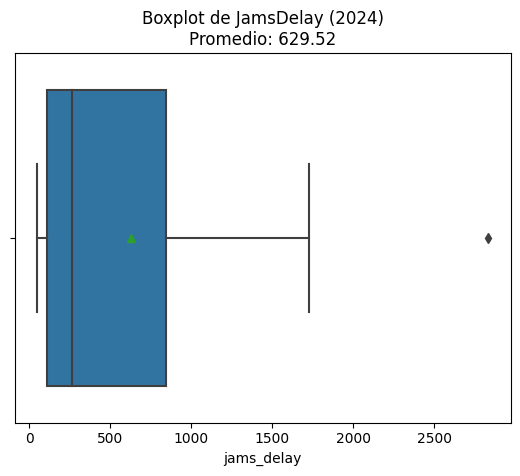

In [22]:
sns.boxplot(data=merged,x="jams_delay",showmeans=True)

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


- Visualización la distribución de la economía (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.

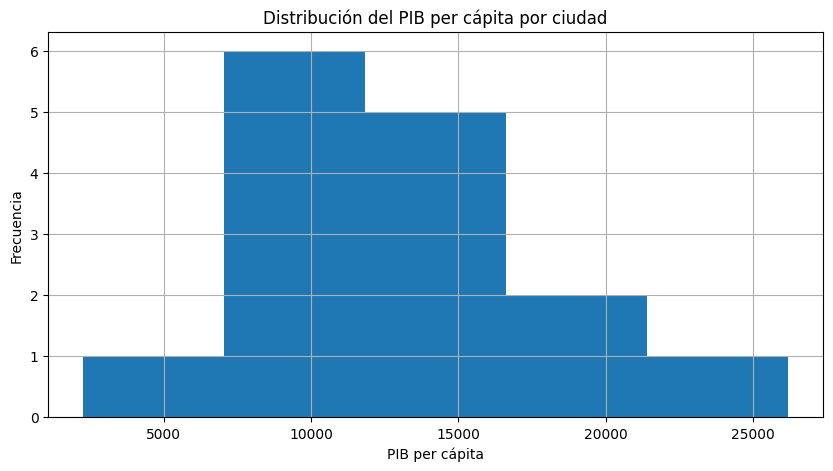

In [24]:
merged['city_gdp_capita'].hist(bins=5,figsize=(10,5))
plt.title("Distribución del PIB per cápita por ciudad")
plt.xlabel("PIB per cápita")
plt.ylabel("Frecuencia")
plt.show()


- Comparación de ambas variables para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.

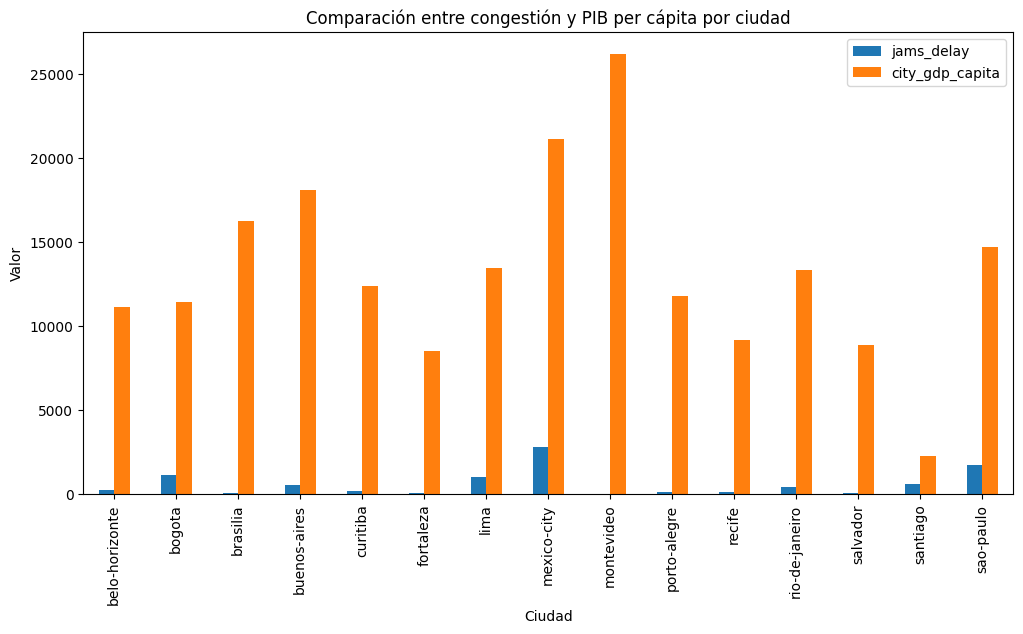

In [25]:
merged.plot(
    x="city",
    y=["jams_delay", "city_gdp_capita"],
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparación entre congestión y PIB per cápita por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Valor")
plt.xticks(rotation=90)
plt.show()


* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Las ciudades con mayor PIB per cápita no necesariamente presentan mayor congestión. Tampoco puede afirmarse que exista una relación inversa. Los datos muestran un comportamiento irregular, por lo que no existe una relación clara o consistente entre el PIB per cápita y la congestión vehicular en las ciudades analizadas. Por ejemplo:

Montevideo presenta el PIB per cápita más alto, pero su congestión es muy baja.
Ciudad de México combina un PIB per cápita alto con el mayor nivel de congestión.
Bogotá tiene una congestión elevada, aunque su PIB per cápita no está entre los más altos.
São Paulo también presenta congestión alta, pero un PIB per cápita intermedio.
Brasilia tiene un PIB relativamente alto y una congestión baja.

In [26]:
# Se exporta el dataset final como CSV con el nombre: ladb_mobility_economy_2024_clean.csv
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---

##  Resumen ejecutivo

### ¿Existe relación entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?

**Contexto & objetivo:**  
El análisis busca identificar la relación entre la movilidad urbana y la productividad económica, utilizando jams_delay como indicador de congestión o retraso vial y city_gdp_capita como medida de PIB per cápita. También se incluye unemployment_pct como variable económica complementaria. En términos generales, los datos no muestran que las ciudades con mayor PIB per cápita tengan necesariamente más o menos congestión.

**Cobertura de datos:**  
El análisis corresponde al año 2024 e incluye 15 ciudades de 7 países: Argentina, Brasil, Chile, Colombia, México, Perú y Uruguay. La cobertura permite realizar una comparación regional.

**Metodología:**  
Se limpiaron y estandarizaron las columnas, corrigiendo formatos de fechas, porcentajes y valores numéricos. Posteriormente, los datos se agregaron a nivel ciudad–año y las tablas de tráfico y economía se integraron mediante una unión INNER, conservando únicamente las ciudades presentes en ambas fuentes. Finalmente, se utilizaron visualizaciones para revisar distribuciones, identificar posibles valores atípicos y observar tendencias generales entre congestión, PIB per cápita y desempleo.

**Hallazgos iniciales:**  
La relación entre congestión y PIB per cápita es positiva, pero débil, por lo que no existe evidencia suficiente para afirmar que las ciudades con mayor productividad económica presentan necesariamente más congestión. Ciudad de México combina el mayor retraso vial con un PIB per cápita alto, mientras que Montevideo registra el PIB per cápita más elevado y uno de los niveles más bajos de congestión. Santiago aparece como un posible outlier debido a que combina congestión relativamente alta con un PIB per cápita considerablemente menor al resto, por lo que el dato debería validarse.

**Recomendaciones**  
Entre Bogotá, Lima y Buenos Aires, Bogotá sería la ciudad prioritaria para inversión en infraestructura de transporte, ya que combina mayor congestión, menor PIB per cápita y mayor desempleo. Santiago podría representar una prioridad aún mayor, pero primero es necesario confirmar que su indicador económico utiliza la misma moneda, unidad y metodología que las demás ciudades. Para fortalecer las decisiones de inversión, se recomienda incorporar varios años de datos y variables como población, densidad urbana, parque vehicular, cobertura de transporte público y duración promedio de los viajes.
